In [ ]:
from __future__ import annotations

import argparse
import importlib.util
import logging
import sys
import time
import types
from pathlib import Path

from src.utils import pmf_utils
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import torch

from src.ddm.ddm import DecisionModel, FreeParam, FixedParam

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

INFO:__main__:Using device: cuda


In [2]:
COHERENCES     = np.array([-0.50, -0.18, -0.09, 0.0, 0.09, 0.18, 0.50]).round(2)
TRIALS_PER_COH = 150
MAX_DURATION     = 3.0
DT               = 0.001
CAF_WEIGHT       = 1
CAF_BINS         = 15
RT_VAR_WEIGHT    = 1

In [3]:
def plot_mean_data(data):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    cohs_sorted = sorted(data["signed_coherence"].unique())


    def summarize(df):
        p_upper = []
        mean_rt_upper, sem_rt_upper = [], []
        mean_rt_lower, sem_rt_lower = [], []
        for c in cohs_sorted:
            subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
            p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
            upper = subset[subset["choice"] == 1]["rt"]
            lower = subset[subset["choice"] == 0]["rt"]
            mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
            sem_rt_upper.append(upper.sem() if len(upper) > 0 else np.nan)
            mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
            sem_rt_lower.append(lower.sem() if len(lower) > 0 else np.nan)
        return np.array(p_upper), np.array(mean_rt_upper), np.array(sem_rt_upper), np.array(mean_rt_lower), np.array(sem_rt_lower)

    p_upper, mean_rt_upper, sem_rt_upper, mean_rt_lower, sem_rt_lower = summarize(data)

    # Psychometric function
    axes[0].plot(cohs_sorted, p_upper, "o-", color="steelblue")
    axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    axes[0].axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    axes[0].set_xlabel("Coherence")
    axes[0].set_ylabel("P(upper boundary)")
    axes[0].set_title("Psychometric Function")
    axes[0].set_ylim(0, 1)

    # Chronometric function
    mean_rt  = []
    sem_rt   = []
    for coh in cohs_sorted:
        subset = data[data["signed_coherence"] == coh].dropna()
        mean_rt.append(subset["rt"].mean())
        sem_rt.append(subset["rt"].sem())

    axes[1].errorbar(cohs_sorted, mean_rt, yerr=sem_rt, fmt="o-", color="tomato", capsize=4)
    axes[1].axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    axes[1].set_xlabel("Coherence")
    axes[1].set_ylabel("Mean RT (s)")
    axes[1].set_title("Chronometric Function")

    #
    # --- Chronometric ---

    ax2 = axes[2]
    ax2.errorbar(cohs_sorted, mean_rt_upper, yerr=sem_rt_upper, fmt="o-", color="steelblue", capsize=4, label="choice 1")
    ax2.errorbar(cohs_sorted, mean_rt_lower, yerr=sem_rt_lower, fmt="o-", color="tomato", capsize=4, label="choice 0")
    ax2.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric")
    ax2.legend()

    # ax2.sharey(axes[1])  # share y-axis with the middle plot|
    axes[1].sharey(ax2)  # share y-axis with the right plot

    plt.tight_layout()
    plt.show()

# for each coherence plot histogram of RTs for choice 0 and choice 1
def plot_raw_data(data):

    fig, axes = plt.subplots(len(data["signed_coherence"].unique()), 1, figsize=(8, 3 * len(data["signed_coherence"].unique())))

    for ax, coh in zip(axes, sorted(data["signed_coherence"].unique())):
        subset = data[data["signed_coherence"] == coh]
        ax.hist(subset[subset["choice"] == 0]["rt"], bins=20, alpha=0.5, label="choice 0", color="steelblue")
        ax.hist(subset[subset["choice"] == 1]["rt"], bins=20, alpha=0.5, label="choice 1", color="tomato")
        ax.set_title(f"Coherence: {coh:+.2f}")
        ax.set_xlabel("RT (s)")
        ax.set_ylabel("Count")
        ax.set_ylim(0, data["rt"].max() + 0.5)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [4]:
fixed_params = {
    "dt": FixedParam(0.001),
    "variance": FixedParam(1.0),
}

free_params = {
    "ndt": FreeParam(0.1, 1),
    "a": FreeParam(0.8, 6.0),
    "z": FreeParam(0.1, 0.9),
    "drift_gain": FreeParam(1.0, 10.0),
    "drift_offset": FreeParam(-5.0, 5.0),
    # "variance": FreeParam(0.5, 2.0),
    "leak_rate": FreeParam(0.0, 0.3),
    "time_constant": FreeParam(-2.0, 2.0),
}

likelihood_params = {
    "chrono_weight": 1.5,
    "caf_weight":    1.5,
    "rt_var_weight": 0.0,
    "caf_bins":      5,
}
class DDMModel(DecisionModel):

    def __init__(self, fixed_params, free_params, likelihood_params=None):

        super().__init__(free_params=free_params, fixed_params=fixed_params, device=device, likelihood_params=likelihood_params)

    def _objective_function(self, values, data, stimulus, n_reps, l1_weight):
        try:
            params = self._build_params(values)
        except ValueError:
            return 1e6
        result = self._simulate_condition(stimulus, params, n_reps)
        if result is None:
            return 1e6
        return self.likelihood_calc.compute_nll(
            result["rt"], result["choice"],
            np.asarray(data["rt"]), np.asarray(data["choice"]),
            result["signed_coherence"], np.asarray(data["signed_coherence"]),
        )

ddm_model = DDMModel(
    fixed_params=fixed_params,
    free_params=free_params,
    likelihood_params=likelihood_params
)

INFO:src.ddm.simulator:DriftDiffusionSimulator using _TorchSimulator backend on cuda
INFO:src.ddm.ddm2:Initialized DDMModel | device=cuda


# Generate Data

In [5]:
def make_stimulus() -> np.ndarray:
    n_tp = int(MAX_DURATION / DT)
    coh  = np.repeat(COHERENCES, TRIALS_PER_COH)
    return np.tile(coh.reshape(-1, 1), (1, n_tp)).astype(np.float32)

def generate_data_simple(params: dict = None, seed: int = None):
    """Like generate_data() but uses the ddm_simple dict-based API."""
    if params is None:
        params = dict(DEFAULT_PARAMS)

    stimulus   = make_stimulus()
    sim_data = ddm_model.simulate(stimulus=stimulus, params=params, seed=seed)

    return sim_data

Data likelihood under original parameters: 0.0
   signed_coherence  n_trials  n_choice_0  n_choice_1  n_nan
0             -0.50       150         148           2      0
1             -0.18       150         124          26      0
2             -0.09       150         103          47      0
3              0.00       150          58          92      0
4              0.09       150          46         104      0
5              0.18       150          34         116      0
6              0.50       150           0         150      0


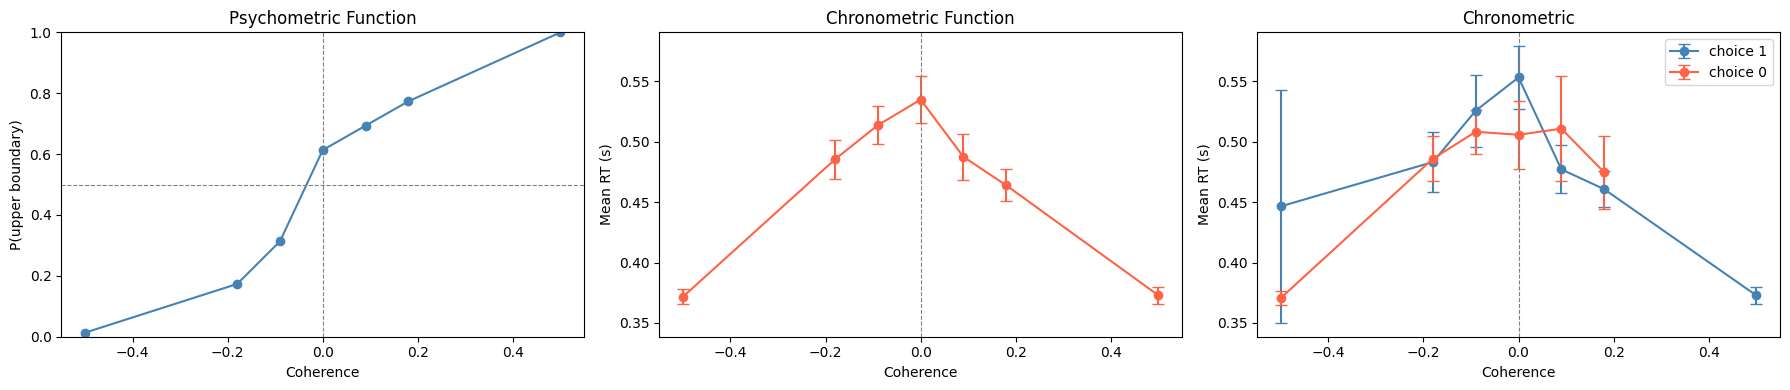

In [6]:
# calculate likelihood for original parameters (before fitting) for comparison
original_params = {
    "ndt": 0.25,
    "a": 1.0,
    "z": 0.5,
    "drift_gain": 8.0,
    "drift_offset": 0.0,
    "variance": 1.0,
    "leak_rate": 0.1,
    "time_constant": 0,#0.5,
    "dt": 0.001,

}

stimulus = make_stimulus()

data = generate_data_simple(params=original_params, seed=42)

# count number of 0, 1 and NaN in each coherence bin
summary = data.groupby("signed_coherence")["choice"].agg(
    n_trials="count",
    n_choice_0=lambda x: np.sum(x == 0),
    n_choice_1=lambda x: np.sum(x == 1),
    n_nan=lambda x: np.sum(np.isnan(x)),
).reset_index()

likelihood = ddm_model.likelihood_calc.compute_nll(
    data["rt"], data["choice"],
    data["rt"], data["choice"],
    data["signed_coherence"], data["signed_coherence"],
)

print(f"Data likelihood under original parameters: {likelihood:.1f}")


print(summary)

plot_mean_data(data)
# plot_raw_data(data)

# Recovery Trial

### DDM Simple

In [7]:
result = ddm_model.fit(
    data={"rt": data["rt"], "choice": data["choice"], "signed_coherence": data["signed_coherence"]},
    stimulus=stimulus,
    max_iterations=900,
    n_reps=15,
    l1_weight=0,
)

INFO:src.ddm.ddm2:Starting optimization (DDMModel)...
INFO:src.ddm.ddm2:Iter   1 | NLL=333.8933 | convergence=0.0022 | ndt=0.1968  a=1.1848  z=0.3432  drift_gain=7.0953  drift_offset=0.0544  leak_rate=0.0974  time_constant=0.3516
INFO:src.ddm.ddm2:Iter   2 | NLL=315.5194 | convergence=0.0245 | ndt=0.1968  a=1.4394  z=0.5016  drift_gain=6.8103  drift_offset=0.0544  leak_rate=0.0828  time_constant=0.6221
INFO:src.ddm.ddm2:Iter   3 | NLL=315.5194 | convergence=0.0172 | ndt=0.1968  a=1.4394  z=0.5016  drift_gain=6.8103  drift_offset=0.0544  leak_rate=0.0828  time_constant=0.6221
INFO:src.ddm.ddm2:Iter   4 | NLL=315.5194 | convergence=0.0157 | ndt=0.1968  a=1.4394  z=0.5016  drift_gain=6.8103  drift_offset=0.0544  leak_rate=0.0828  time_constant=0.6221
INFO:src.ddm.ddm2:Iter   5 | NLL=315.5194 | convergence=0.0159 | ndt=0.1968  a=1.4394  z=0.5016  drift_gain=6.8103  drift_offset=0.0544  leak_rate=0.0828  time_constant=0.6221
INFO:src.ddm.ddm2:Iter   6 | NLL=315.5194 | convergence=0.0141 | n

# plot model simulations

In [8]:
def plot_ddm_fit(data, sim, coherences=None, title="DDM Fit"):
    """
    Overlay observed data (dots) and model predictions (lines).

    data : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    sim  : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    """
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    if not isinstance(sim, pd.DataFrame):
        sim = pd.DataFrame(sim)

    cohs = sorted(coherences if coherences is not None else data["signed_coherence"].unique())

    def summarize(df):
        p_upper, mean_rt_upper, mean_rt_lower = [], [], []
        for c in cohs:
            subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
            p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
            upper = subset[subset["choice"] == 1]["rt"]
            lower = subset[subset["choice"] == 0]["rt"]
            mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
            mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
        return np.array(p_upper), np.array(mean_rt_upper), np.array(mean_rt_lower)

    d_p, d_rt1, d_rt0 = summarize(data)
    s_p, s_rt1, s_rt0 = summarize(sim)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(title)

    # --- Psychometric ---
    ax1.plot(cohs, s_p, color="steelblue", label="model")
    ax1.scatter(cohs, d_p, color="steelblue", zorder=5, label="data")
    ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set(xlabel="Coherence", ylabel="P(upper boundary)", title="Psychometric", ylim=(0, 1))
    ax1.legend()

    # --- Chronometric ---
    ax2.plot(cohs, s_rt1, color="steelblue", label="model upper")
    ax2.plot(cohs, s_rt0, color="tomato",    label="model lower")
    ax2.scatter(cohs, d_rt1, color="steelblue", zorder=5, label="data upper")
    ax2.scatter(cohs, d_rt0, color="tomato",    zorder=5, label="data lower")
    ax2.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric")
    ax2.legend()

    plt.tight_layout()
    return fig

In [9]:
# sae model results
with open("model_results_simple.pkl", "wb") as f:
    torch.save(result, f)

## Likelihood Calculator

In [10]:
def model_comparison():
    # fitted_params = simple_model_cuda._build_params(
    #     [result["parameters"][k] for k in result["parameters"]]
    # )
    fitted_params = result["parameters"]
    sim_data = ddm_model.simulate(stimulus, params=fitted_params)
    return sim_data

In [11]:
with open("model_results_simple.pkl", "rb") as f:
    result = torch.load(f)

In [12]:
fitted_llh, origin_param_llh = [], []

sim_data_original  = ddm_model.simulate(
    stimulus, params=result["parameters"]
)

for i in range(1):
    sim_data_cuda = model_comparison()

    llh_cuda = ddm_model.likelihood_calc.compute_nll(
        sim_data_cuda["rt"].values, sim_data_cuda["choice"].values,
        data["rt"].values, data["choice"].values,
        sim_data_cuda["signed_coherence"].values, data["signed_coherence"].values,
    )
    llh_original_param = ddm_model.likelihood_calc.compute_nll(
        sim_data_original["rt"].values, sim_data_original["choice"].values,
        data["rt"].values, data["choice"].values,
        sim_data_original["signed_coherence"].values, data["signed_coherence"].values,
    )

    fitted_llh.append(llh_cuda)
    origin_param_llh.append(llh_original_param)

llh_data = ddm_model.likelihood_calc.compute_nll(
    data["rt"].values, data["choice"].values,
    data["rt"].values, data["choice"].values,
    data["signed_coherence"].values, data["signed_coherence"].values,
)

print(f"Data vs itself:   {llh_data:.1f}  (should be 0)")
print(f"Original params:  {np.mean(origin_param_llh):.1f} ± {np.std(origin_param_llh):.1f}")
print(f"Fitted params:    {np.mean(fitted_llh):.1f} ± {np.std(fitted_llh):.1f}  (should be ≤ original)")

Data vs itself:   0.0  (should be 0)
Original params:  41.9 ± 0.0
Fitted params:    41.9 ± 0.0  (should be ≤ original)


In [13]:
def plot_ddm_fit(data, sim, coherences=None, title="DDM Fit"):
    """
    Overlay observed data (dots) and model predictions (lines).

    data : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    sim  : DataFrame or dict with keys 'rt', 'choice', 'coherence'
    """
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    if not isinstance(sim, pd.DataFrame):
        sim = pd.DataFrame(sim)

    data = data.copy()
    sim  = sim.copy()
    data["signed_coherence"] = data["signed_coherence"].round(2)
    sim["signed_coherence"]  = sim["signed_coherence"].round(2)

    cohs = sorted(coherences if coherences is not None else data["signed_coherence"].unique())

    def summarize(df):
        p_upper, mean_rt_upper, mean_rt_lower = [], [], []
        for c in cohs:
            subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
            p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
            upper = subset[subset["choice"] == 1]["rt"]
            lower = subset[subset["choice"] == 0]["rt"]
            mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
            mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
        return np.array(p_upper), np.array(mean_rt_upper), np.array(mean_rt_lower)

    d_p, d_rt1, d_rt0 = summarize(data)
    s_p, s_rt1, s_rt0 = summarize(sim)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(title)

    # --- Psychometric ---
    ax1.plot(cohs, s_p, color="steelblue", label="model")
    ax1.scatter(cohs, d_p, color="steelblue", zorder=5, label="data")
    ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set(xlabel="Coherence", ylabel="P(upper boundary)", title="Psychometric", ylim=(0, 1))
    ax1.legend()

    # --- Chronometric ---
    ax2.plot(cohs, s_rt1, color="steelblue", label="model upper")
    ax2.plot(cohs, s_rt0, color="tomato",    label="model lower")
    ax2.scatter(cohs, d_rt1, color="steelblue", zorder=5, label="data upper")
    ax2.scatter(cohs, d_rt0, color="tomato",    zorder=5, label="data lower")
    ax2.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric")
    ax2.legend()

    plt.tight_layout()
    # return fig

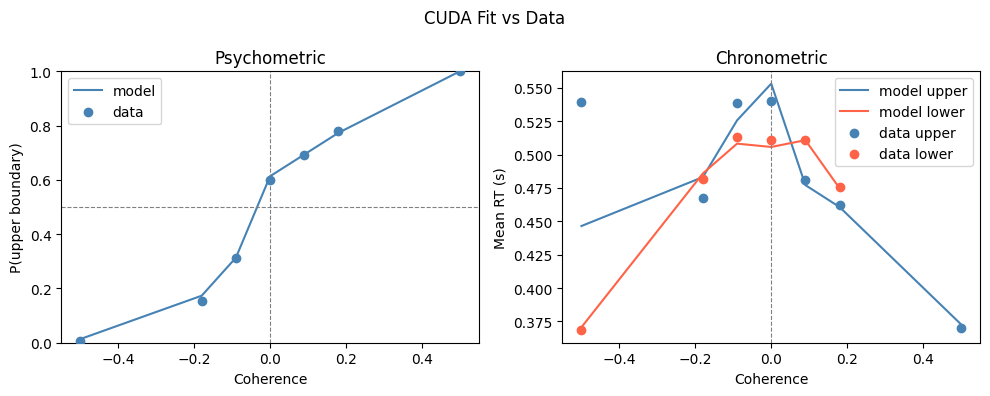

In [14]:
plot_ddm_fit(sim_data_cuda, data, title="CUDA Fit vs Data")

# Hyperparameter Tuning

Grid: 36 configs × 300 DE iters (~54–108 min total)

[  1/36] ch=0.5_caf=0.5_var=0.0 ... 

INFO:src.ddm.simulator:DriftDiffusionSimulator using _TorchSimulator backend on cuda
INFO:src.ddm.ddm2:Initialized DDMModel | device=cuda
INFO:src.ddm.ddm2:Optimization successful.


composite=0.0359  (psychometric=0.0543, chrono_upper=0.0364, chrono_lower=0.0170)  121s
[  2/36] ch=0.5_caf=0.5_var=0.5 ... 

INFO:src.ddm.simulator:DriftDiffusionSimulator using _TorchSimulator backend on cuda
INFO:src.ddm.ddm2:Initialized DDMModel | device=cuda
INFO:src.ddm.ddm2:Optimization successful.


composite=0.0421  (psychometric=0.0615, chrono_upper=0.0450, chrono_lower=0.0200)  169s
[  3/36] ch=0.5_caf=0.5_var=1.0 ... 

...

composite=0.0344  (psychometric=0.0531, chrono_upper=0.0367, chrono_lower=0.0134)  129s
[ 35/36] ch=4.0_caf=2.0_var=0.5 ... 

INFO:src.ddm.simulator:DriftDiffusionSimulator using _TorchSimulator backend on cuda
INFO:src.ddm.ddm2:Initialized DDMModel | device=cuda
INFO:src.ddm.ddm2:Optimization successful.


composite=0.0363  (psychometric=0.0639, chrono_upper=0.0306, chrono_lower=0.0143)  115s
[ 36/36] ch=4.0_caf=2.0_var=1.0 ... 

INFO:src.ddm.simulator:DriftDiffusionSimulator using _TorchSimulator backend on cuda
INFO:src.ddm.ddm2:Initialized DDMModel | device=cuda
INFO:src.ddm.ddm2:Optimization successful.


composite=0.0382  (psychometric=0.0626, chrono_upper=0.0384, chrono_lower=0.0135)  303s

=== Top 5 configs ===
                 label  composite  psychometric  chrono_upper  chrono_lower
ch=2.0_caf=2.0_var=0.0   0.031811      0.053273      0.025528      0.016633
ch=2.0_caf=0.5_var=0.0   0.034034      0.051552      0.039664      0.010886
ch=2.0_caf=1.0_var=0.0   0.034065      0.051545      0.040942      0.009707
ch=4.0_caf=2.0_var=0.0   0.034426      0.053135      0.036711      0.013431
ch=4.0_caf=0.5_var=0.0   0.034910      0.049716      0.041154      0.013859


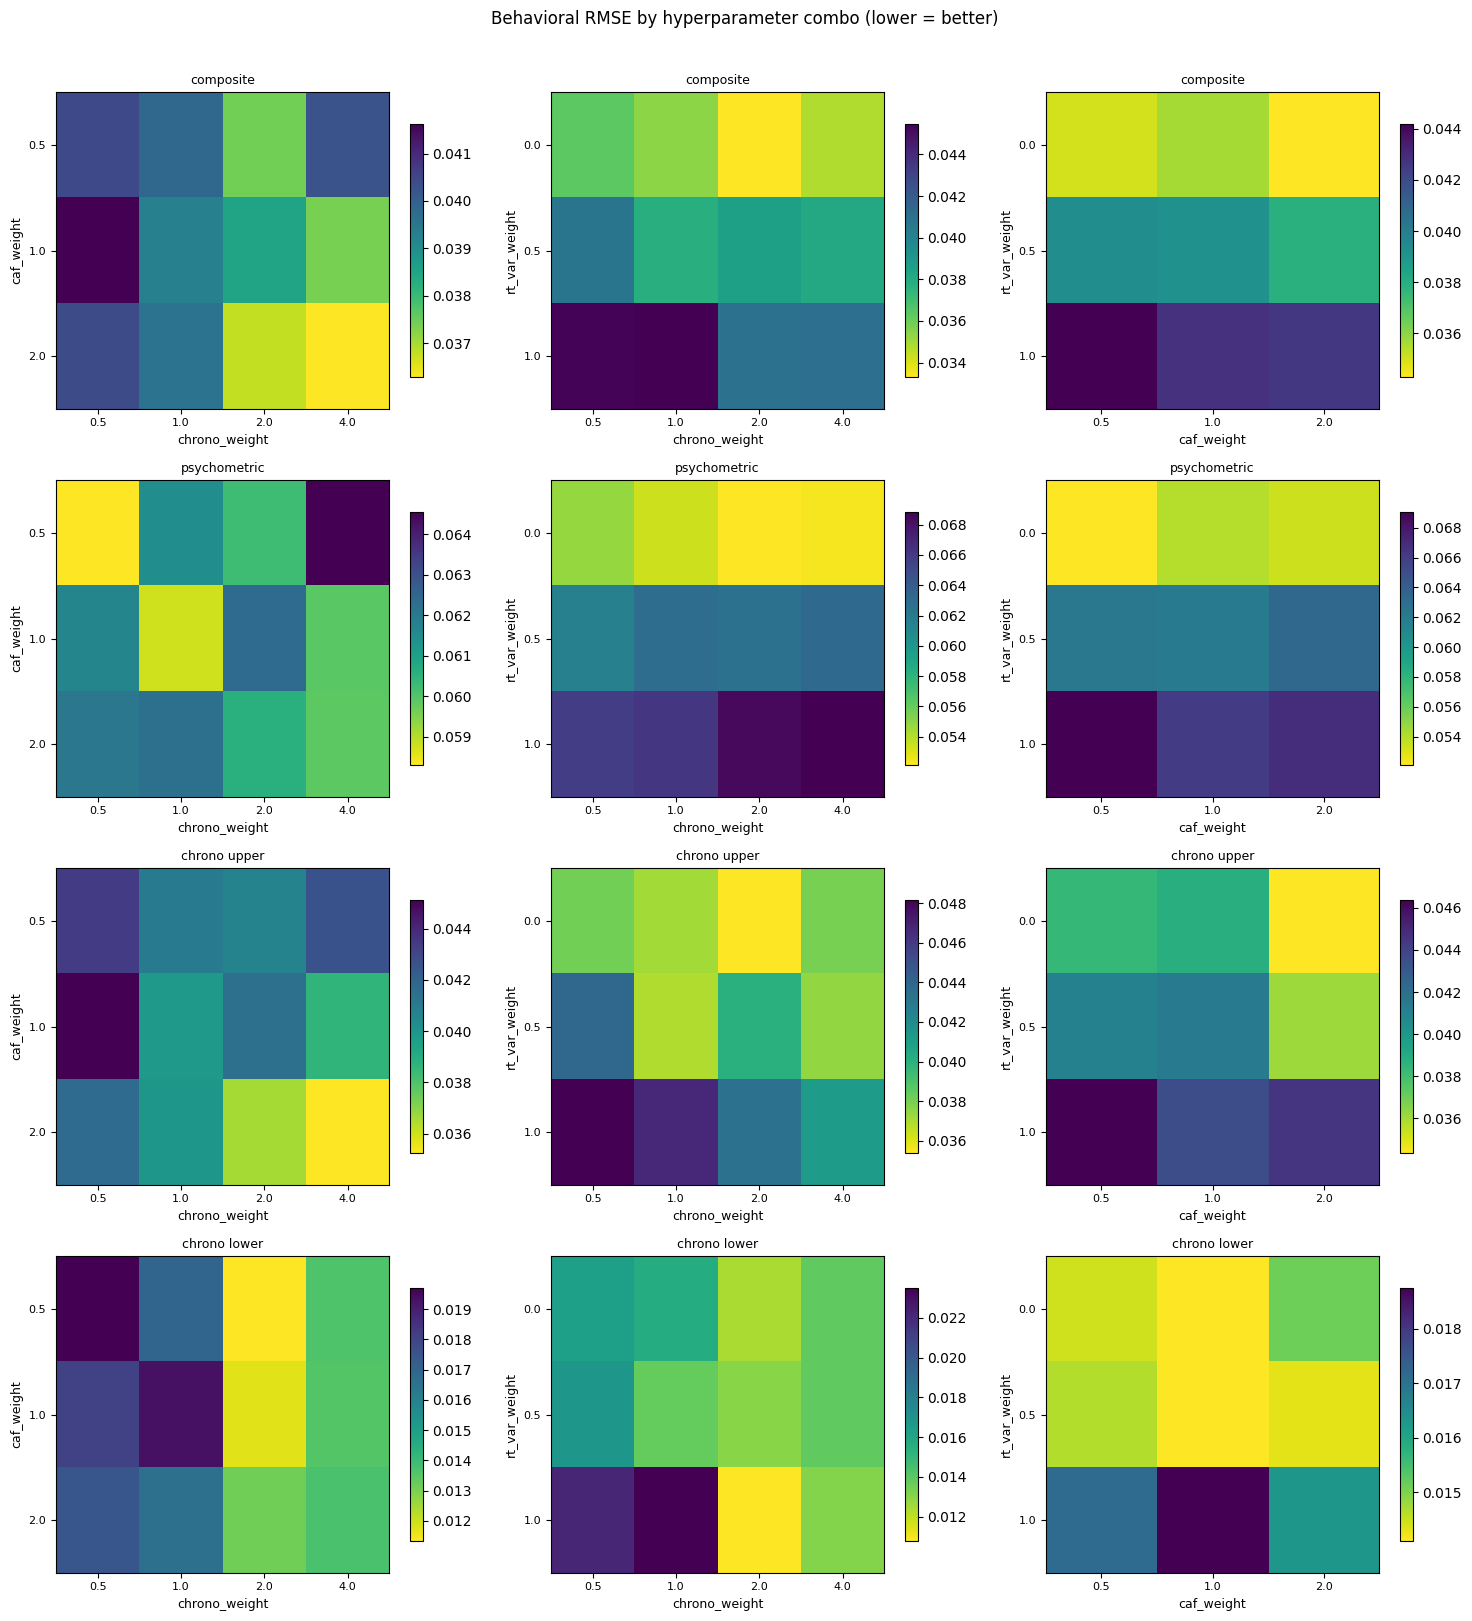

,label,chrono_weight,caf_weight,rt_var_weight,composite,psychometric,chrono_upper,chrono_lower,nll,elapsed_s
0,ch=2.0_caf=2.0_var=0.0,2.0,2.0,0.0,0.031811,0.053273,0.025528,0.016633,53.924258,95.746915
1,ch=2.0_caf=0.5_var=0.0,2.0,0.5,0.0,0.034034,0.051552,0.039664,0.010886,43.536324,144.056340
2,ch=2.0_caf=1.0_var=0.0,2.0,1.0,0.0,0.034065,0.051545,0.040942,0.009707,44.354538,91.127390
3,ch=4.0_caf=2.0_var=0.0,4.0,2.0,0.0,0.034426,0.053135,0.036711,0.013431,45.152450,129.458992
4,ch=4.0_caf=0.5_var=0.0,4.0,0.5,0.0,0.034910,0.049716,0.041154,0.013859,44.160764,106.815247
5,ch=4.0_caf=1.0_var=0.0,4.0,1.0,0.0,0.034932,0.054191,0.036194,0.014410,45.139666,93.090004
6,ch=1.0_caf=0.5_var=0.0,1.0,0.5,0.0,0.035030,0.052772,0.036280,0.016038,41.938402,98.194125
7,ch=1.0_caf=2.0_var=0.0,1.0,2.0,0.0,0.035192,0.053092,0.038924,0.013560,42.193574,111.610192
8,ch=0.5_caf=2.0_var=0.0,0.5,2.0,0.0,0.035743,0.054112,0.036237,0.016881,42.288352,101.779763
9,ch=0.5_caf=0.5_var=0.0,0.5,0.5,0.0,0.035895,0.054310,0.036407,0.016967,40.756476,121.131244


In [15]:
import os

cwd = os.getcwd()
if cwd == "/src/notebooks":
    os.chdir("..")

from scripts.ddm.hyperparameter_tuning import run_tuning, plot_best_fit, build_param_grid
from pathlib import Path

# Narrow grid first — expand once you see which region works best.
# ~36 configs × ~5 min each ≈ 3 h on GPU; reduce max_iter to 150 for a quick scan.
TUNING_SAVE = Path("tuning_cache.pkl")

results_df = run_tuning(
    data=data,           # use the synthetic data already in memory
    stimulus=stimulus,   # same stimulus
    chrono_weights=[0.5, 1.0, 2.0, 4.0],
    caf_weights=[0.5, 1.0, 2.0],
    rt_var_weights=[0.0, 0.5, 1.0],
    n_reps=5,            # reduced for speed; use 15 for the final fit
    max_iter=300,        # reduced for speed; use 1000 for the final fit
    save_path=TUNING_SAVE,
    resume=True,         # safe to re-run: skips already-completed configs
)

results_df.head(10)

Grid: 16 configs × 300 DE iters (~24–48 min total)

Resuming: 6/16 configs already done.
[  7/16] ch=1.5_caf=2.5_var=0.0 ... 

INFO:src.ddm.simulator:DriftDiffusionSimulator using _NumbaSimulator backend on cpu
INFO:src.ddm.ddm2:Initialized DDMModel | device=cpu
INFO:src.ddm.ddm2:Optimization successful.


composite=0.0215  (psychometric=0.0268, chrono_upper=0.0152, chrono_lower=0.0225)  nll=21.3  249s
[  8/16] ch=1.5_caf=3.0_var=0.0 ... 

INFO:src.ddm.simulator:DriftDiffusionSimulator using _NumbaSimulator backend on cpu
INFO:src.ddm.ddm2:Initialized DDMModel | device=cpu
INFO:src.ddm.ddm2:Optimization successful.


composite=0.0222  (psychometric=0.0298, chrono_upper=0.0149, chrono_lower=0.0217)  nll=21.4  193s
[  9/16] ch=2.0_caf=1.5_var=0.0 ... 

...

composite=0.0211  (psychometric=0.0271, chrono_upper=0.0137, chrono_lower=0.0223)  nll=21.9  166s
[ 15/16] ch=2.5_caf=2.5_var=0.0 ... 

INFO:src.ddm.simulator:DriftDiffusionSimulator using _NumbaSimulator backend on cpu
INFO:src.ddm.ddm2:Initialized DDMModel | device=cpu
INFO:src.ddm.ddm2:Optimization successful.


composite=0.0208  (psychometric=0.0284, chrono_upper=0.0134, chrono_lower=0.0206)  nll=22.0  171s
[ 16/16] ch=2.5_caf=3.0_var=0.0 ... 

INFO:src.ddm.simulator:DriftDiffusionSimulator using _NumbaSimulator backend on cpu
INFO:src.ddm.ddm2:Initialized DDMModel | device=cpu
INFO:src.ddm.ddm2:Optimization successful.


composite=0.0207  (psychometric=0.0280, chrono_upper=0.0136, chrono_lower=0.0204)  nll=22.2  227s

=== Top 5 configs ===
                 label  composite  psychometric  chrono_upper  chrono_lower       nll
ch=1.5_caf=1.5_var=0.0   0.020618      0.028399      0.013069      0.020386 20.715690
ch=2.5_caf=3.0_var=0.0   0.020656      0.027988      0.013560      0.020422 22.167031
ch=2.5_caf=2.5_var=0.0   0.020785      0.028384      0.013417      0.020554 21.958896
ch=2.0_caf=3.0_var=0.0   0.020915      0.028263      0.014307      0.020173 21.686705
ch=1.0_caf=1.5_var=0.0   0.021025      0.027348      0.015943      0.019783 20.810691


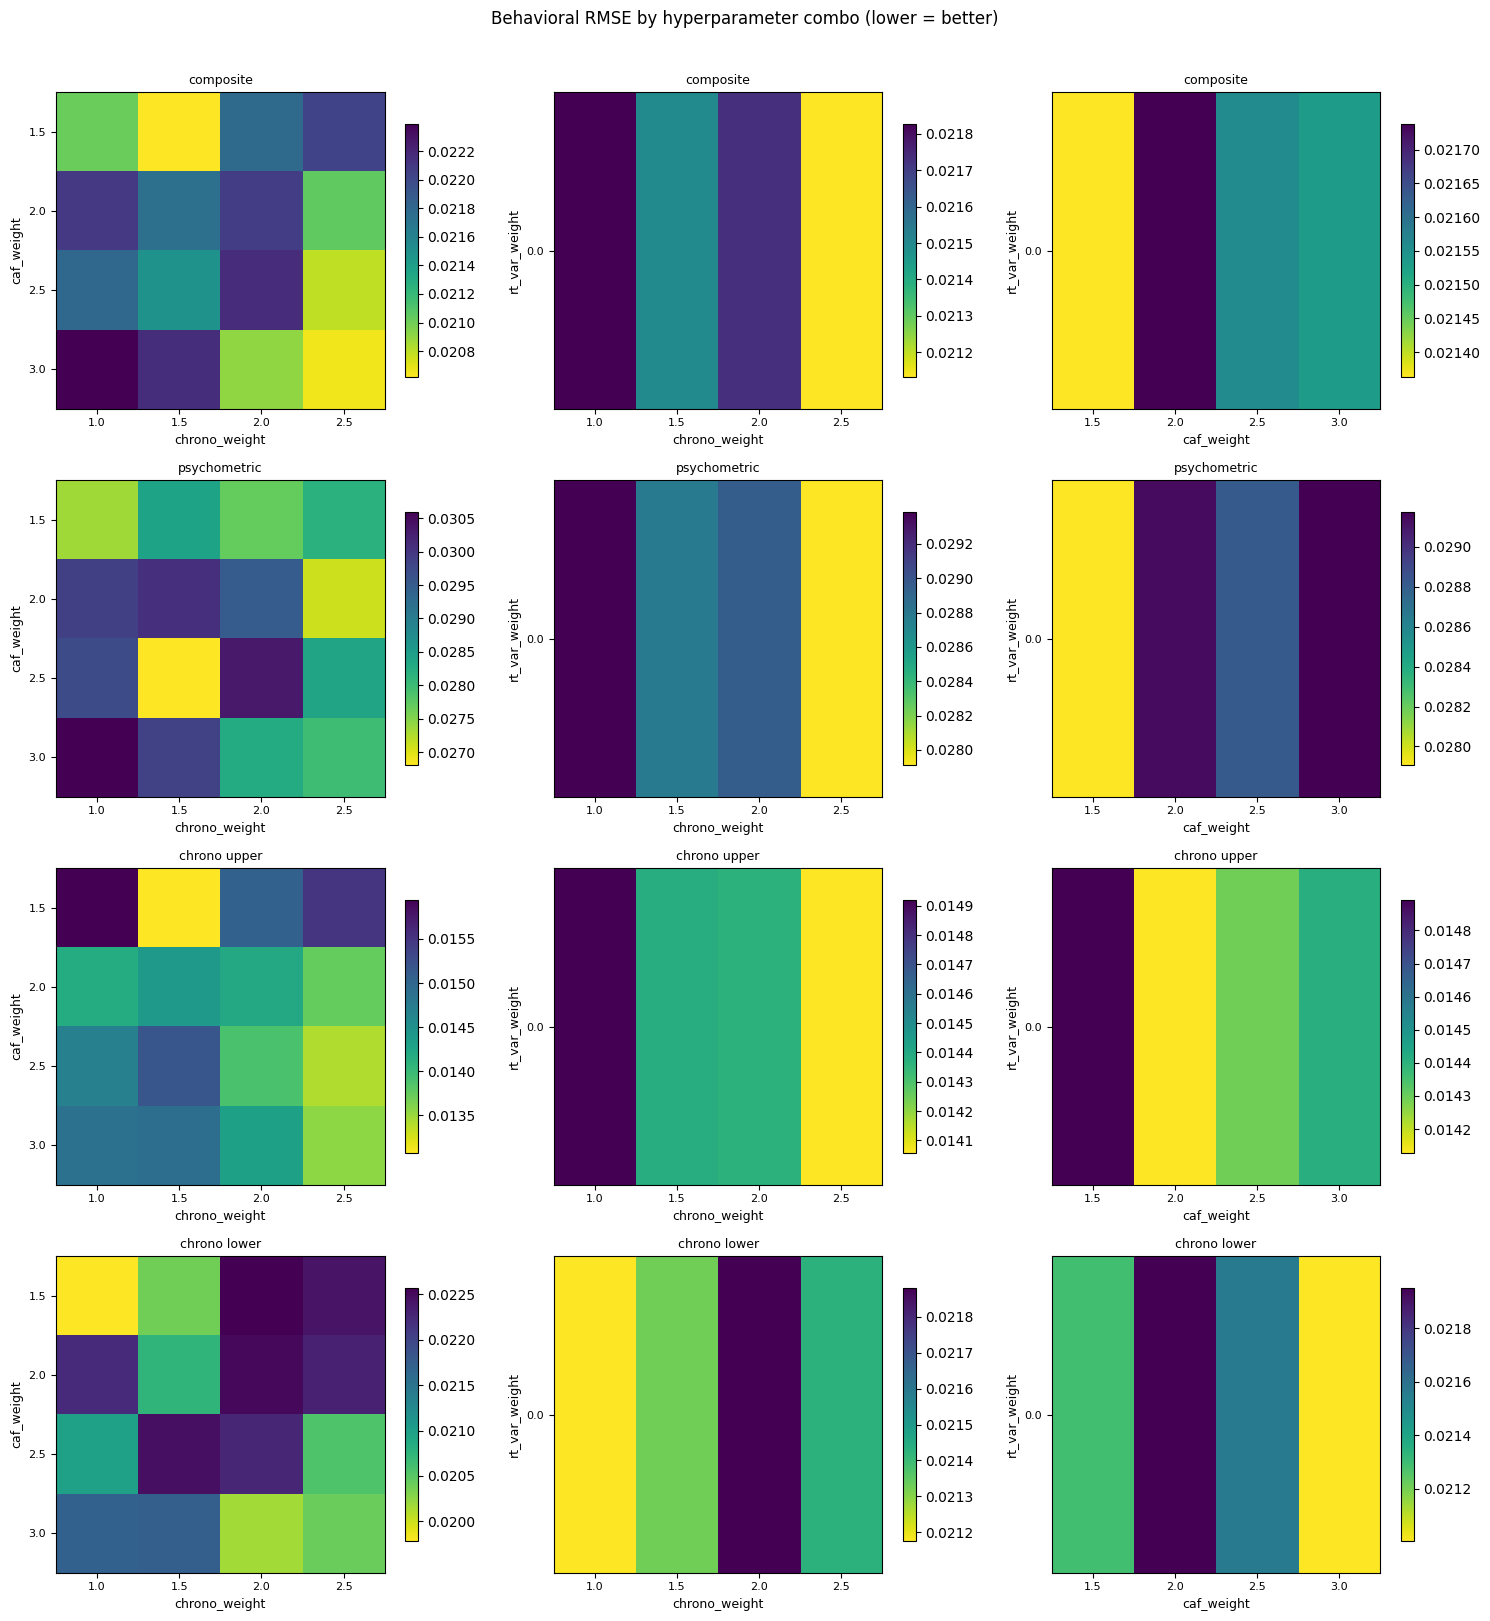

,label,chrono_weight,caf_weight,rt_var_weight,composite,psychometric,chrono_upper,chrono_lower,nll,elapsed_s
0,ch=1.5_caf=1.5_var=0.0,1.5,1.5,0.0,0.020618,0.028399,0.013069,0.020386,20.715690,214.983212
1,ch=2.5_caf=3.0_var=0.0,2.5,3.0,0.0,0.020656,0.027988,0.013560,0.020422,22.167031,227.153950
2,ch=2.5_caf=2.5_var=0.0,2.5,2.5,0.0,0.020785,0.028384,0.013417,0.020554,21.958896,170.864214
3,ch=2.0_caf=3.0_var=0.0,2.0,3.0,0.0,0.020915,0.028263,0.014307,0.020173,21.686705,218.753982
4,ch=1.0_caf=1.5_var=0.0,1.0,1.5,0.0,0.021025,0.027348,0.015943,0.019783,20.810691,158.172439
5,ch=2.5_caf=2.0_var=0.0,2.5,2.0,0.0,0.021052,0.027100,0.013744,0.022313,21.931244,166.308730
6,ch=1.5_caf=2.5_var=0.0,1.5,2.5,0.0,0.021478,0.026807,0.015170,0.022457,21.347425,249.264886
7,ch=1.5_caf=2.0_var=0.0,1.5,2.0,0.0,0.021736,0.030076,0.014390,0.020742,21.217844,194.825884
8,ch=2.0_caf=1.5_var=0.0,2.0,1.5,0.0,0.021776,0.027707,0.015051,0.022569,21.373553,175.471812
9,ch=1.0_caf=2.5_var=0.0,1.0,2.5,0.0,0.021798,0.029726,0.014692,0.020977,20.639811,174.295656


In [7]:
import os

cwd = os.getcwd()
if cwd == "/src/notebooks":
    os.chdir("..")

from scripts.ddm.hyperparameter_tuning import run_tuning, plot_best_fit, build_param_grid
from pathlib import Path

# Narrow grid first — expand once you see which region works best.
# ~36 configs × ~5 min each ≈ 3 h on GPU; reduce max_iter to 150 for a quick scan.
TUNING_SAVE = Path("tuning_cache2.pkl")

results_df = run_tuning(
    data=data,           # use the synthetic data already in memory
    stimulus=stimulus,   # same stimulus
    chrono_weights=[1.0, 1.5, 2.0, 2.5],
    caf_weights=[1.5, 2.0, 2.5, 3.0],
    rt_var_weights=[0.0],
    n_reps=5,            # reduced for speed; use 15 for the final fit
    max_iter=300,        # reduced for speed; use 1000 for the final fit
    save_path=TUNING_SAVE,
    resume=True,         # safe to re-run: skips already-completed configs
)

results_df.head(10)

In [3]:
import pickle
import os

cwd = os.getcwd()
if cwd == "/src/notebooks":
    os.chdir("..")

with open("tuning_cache2.pkl", "rb") as f:
    results_df = pickle.load(f)

In [6]:
import pandas as pd

results = pd.DataFrame(results_df)

In [7]:
results

,config,label,psychometric,chrono_upper,chrono_lower,composite,nll,parameters,elapsed_s
0,"TuningConfig(chrono_weight=1.0, caf_weight=1.5...",ch=1.0_caf=1.5_var=0.0,0.027348,0.015943,0.019783,0.021025,20.810691,"{'dt': 0.001, 'variance': 1.0, 'ndt': 0.250554...",158.172439
1,"TuningConfig(chrono_weight=1.0, caf_weight=2.0...",ch=1.0_caf=2.0_var=0.0,0.029878,0.014167,0.022239,0.022095,20.942508,"{'dt': 0.001, 'variance': 1.0, 'ndt': 0.250525...",126.900523
2,"TuningConfig(chrono_weight=1.0, caf_weight=2.5...",ch=1.0_caf=2.5_var=0.0,0.029726,0.014692,0.020977,0.021798,20.639811,"{'dt': 0.001, 'variance': 1.0, 'ndt': 0.250586...",174.295656
3,"TuningConfig(chrono_weight=1.0, caf_weight=3.0...",ch=1.0_caf=3.0_var=0.0,0.030593,0.014875,0.021704,0.022391,21.089796,"{'dt': 0.001, 'variance': 1.0, 'ndt': 0.250571...",188.468755
4,"TuningConfig(chrono_weight=1.5, caf_weight=1.5...",ch=1.5_caf=1.5_var=0.0,0.028399,0.013069,0.020386,0.020618,20.715690,"{'dt': 0.001, 'variance': 1.0, 'ndt': 0.250542...",214.983212
5,"TuningConfig(chrono_weight=1.5, caf_weight=2.0...",ch=1.5_caf=2.0_var=0.0,0.030076,0.014390,0.020742,0.021736,21.217844,"{'dt': 0.001, 'variance': 1.0, 'ndt': 0.250604...",194.825884
6,"TuningConfig(chrono_weight=1.5, caf_weight=2.5...",ch=1.5_caf=2.5_var=0.0,0.026807,0.015170,0.022457,0.021478,21.347425,"{'dt': 0.001, 'variance': 1.0, 'ndt': 0.250540...",249.264886
7,"TuningConfig(chrono_weight=1.5, caf_weight=3.0...",ch=1.5_caf=3.0_var=0.0,0.029848,0.014904,0.021724,0.022159,21.365878,"{'dt': 0.001, 'variance': 1.0, 'ndt': 0.250546...",193.412716
8,"TuningConfig(chrono_weight=2.0, caf_weight=1.5...",ch=2.0_caf=1.5_var=0.0,0.027707,0.015051,0.022569,0.021776,21.373553,"{'dt': 0.001, 'variance': 1.0, 'ndt': 0.250558...",175.471812
9,"TuningConfig(chrono_weight=2.0, caf_weight=2.0...",ch=2.0_caf=2.0_var=0.0,0.029492,0.014208,0.022505,0.022068,21.860963,"{'dt': 0.001, 'variance': 1.0, 'ndt': 0.250590...",179.317295


In [ ]:
print("\n=== Top 5 configs ===")
cols = ["label", "composite", "psychometric", "chrono_upper", "chrono_lower", "nll"]
print(results_df[cols].head().to_string(index=False))